# How the concept of *Astronomer* changed over time

This notebook traces the **continuous evolution** of co-occupations attached to people identified as *astronomers* in the database.
Rather than collapsing history into three coarse periods, we slice time into 100-year bins and show, for each bin, the share of contemporary astronomers who also held each of the most common secondary occupations.

The resulting figure is a time-series heatmap: the x-axis is calendar time, the y-axis is the top co-occupations, and the colour intensity is the within-period share. A marginal line above the heatmap shows how many astronomers populate each period.

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Time binning
BIN_WIDTH = 100          # years per period
YEAR_MIN = -500          # include classical antiquity onward
YEAR_MAX = 1950          # data ends cleanly here
MIN_N_PER_BIN = 15       # bins with < this many astronomers are dropped (too noisy)
TOP_N_OCCUPATIONS = 14   # rows of the heatmap

# Variants of "astronomer" itself: excluded from the co-occupation set
ASTRONOMER_VARIANTS = {
    "astronomer", "amateur astronomer", "radio astronomer",
    "archaeoastronomer", "astronomer royal",
}

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (12, 7)
DPI = 200
FONT_TITLE = 14
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette
COLOR_PRIMARY = "#2171b5"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

## 1. Load astronomer records

We pull every individual whose `occupations_en` field contains *astronomer* and join with the impact-date table, which already encodes the period of their cultural activity.

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

query = """
    SELECT i.wikidata_id,
           i.occupations_en,
           CAST(SUBSTR(
               CASE WHEN d.impact_date LIKE '-%' THEN SUBSTR(d.impact_date, 1, 5)
                    ELSE SUBSTR(d.impact_date, 1, 4)
               END, 1, 5) AS INTEGER) AS impact_year
    FROM individuals i
    JOIN individuals_impact_date d ON i.wikidata_id = d.wikidata_id
    WHERE i.occupations_en LIKE '%astronomer%'
      AND d.impact_date IS NOT NULL
"""
df_raw = pd.read_sql(query, conn)
conn.close()

print(f"Loaded {len(df_raw):,} astronomer records")
assert df_raw["wikidata_id"].is_unique, "Expected one row per astronomer"
df_raw.head()

Loaded 9,215 astronomer records


,wikidata_id,occupations_en,impact_year
0,Q1000193,astronomer,1964
1,Q1001072,astronomer; mathematician; civil servant; writ...,1807
2,Q100113735,astronomer; pedagogue; mathematician; physicia...,1600
3,Q100199667,astronomer; writer,1922
4,Q100258349,astronomer; mathematician; military officer; w...,1881


## 2. Parse co-occupations and assign each astronomer to a time bin

Each astronomer gets:
* a **period**: the 100-year bucket containing their `impact_year`, restricted to `YEAR_MIN`..`YEAR_MAX`;
* a **co-occupations list**: their other occupations, with all variants of *astronomer* removed.

In [3]:
def split_occs(s: str) -> list[str]:
    return [o.strip() for o in s.split(";") if o.strip()]

def co_occupations(occs: list[str]) -> list[str]:
    return [o for o in occs if o.lower() not in ASTRONOMER_VARIANTS]

df = df_raw.copy()
df = df[(df["impact_year"] >= YEAR_MIN) & (df["impact_year"] <= YEAR_MAX)].copy()
n_dropped = len(df_raw) - len(df)
print(f"After year filter [{YEAR_MIN}, {YEAR_MAX}]: {len(df):,} rows ({n_dropped} dropped)")

# Period = left edge of the 100-year bin, e.g. impact_year=1623 -> 1600
df["period"] = (np.floor(df["impact_year"] / BIN_WIDTH) * BIN_WIDTH).astype(int)
df["co_occs"] = df["occupations_en"].apply(split_occs).apply(co_occupations)
df["n_co_occs"] = df["co_occs"].apply(len)

df.sample(5, random_state=SEED)

After year filter [-500, 1950]: 4,920 rows (4295 dropped)


,wikidata_id,occupations_en,impact_year,period,co_occs,n_co_occs
927,Q112648,astronomer; climatologist; university teacher;...,1894,1800,"[climatologist, university teacher, physicist,...",4
9206,Q99524206,head teacher; astronomer; mathematician; teach...,1892,1800,"[head teacher, mathematician, teacher, textboo...",5
3253,Q1974064,astronomer; teacher,1920,1900,[teacher],1
5895,Q4720379,astronomer,1892,1800,[],0
7394,Q63342040,pharmacist; astronomer,1921,1900,[pharmacist],1


## 3. Build the full set of 100-year periods

We keep **every** 100-year bin in `[YEAR_MIN, YEAR_MAX]` so the time axis is continuous and ticks appear at every period. Bins with fewer than `MIN_N_PER_BIN` astronomers are flagged as *sparse* — their shares are masked (shown as gray) in the figure rather than dropped from the axis.

In [4]:
# Full continuous list of 100-year periods (left edges) within [YEAR_MIN, YEAR_MAX]
all_periods = list(range(YEAR_MIN, YEAR_MAX, BIN_WIDTH))

period_counts = (
    df.groupby("period").size().rename("n_astronomers")
      .reindex(all_periods, fill_value=0)
      .reset_index()
)
period_counts["sparse"] = period_counts["n_astronomers"] < MIN_N_PER_BIN

n_sparse = int(period_counts["sparse"].sum())
print(f"Total 100-year periods in range: {len(all_periods)}")
print(f"  with >= {MIN_N_PER_BIN} astronomers (shown): {len(all_periods) - n_sparse}")
print(f"  sparse (masked in heatmap):                  {n_sparse}")

period_counts

Total 100-year periods in range: 25
  with >= 15 astronomers (shown): 14
  sparse (masked in heatmap):                  11


,period,n_astronomers,sparse
0,-500,12,True
1,-400,18,False
2,-300,12,True
3,-200,10,True
4,-100,9,True
5,0,6,True
6,100,10,True
7,200,5,True
8,300,4,True
9,400,6,True


## 4. Select the top co-occupations

Across the **non-sparse** periods we count how often each non-astronomer occupation appears, and keep the `TOP_N_OCCUPATIONS` most frequent. These are the rows of the heatmap.

In [5]:
from collections import Counter

non_sparse_periods = period_counts.loc[~period_counts["sparse"], "period"].tolist()
df_dense = df[df["period"].isin(non_sparse_periods)]

global_counts = Counter()
for occs in df_dense["co_occs"]:
    global_counts.update(set(occs))   # one count per astronomer

top_occs = [o for o, _ in global_counts.most_common(TOP_N_OCCUPATIONS)]
top_df = pd.DataFrame(
    [(o, global_counts[o], global_counts[o] / len(df_dense)) for o in top_occs],
    columns=["occupation", "n_astronomers", "share"],
)
top_df

,occupation,n_astronomers,share
0,mathematician,1297,0.268586
1,university teacher,754,0.156140
2,physicist,513,0.106233
3,writer,336,0.069580
4,astrologer,272,0.056326
5,philosopher,229,0.047422
6,physician,188,0.038931
7,politician,161,0.033340
8,astrophysicist,141,0.029199
9,cartographer,139,0.028784


## 5. Build the period × occupation share matrix

For each 100-year bin and each top occupation we compute, **independently per period**:

$$\text{share}_{p,o} = \frac{\#\{\text{astronomers in } p \text{ also } o\}}{\#\{\text{astronomers in } p\}}$$

Sparse periods are filled with `NaN` so the time axis stays continuous. Each column therefore answers: *of the astronomers active during this 100-year window, what fraction also held occupation o?*

In [6]:
matrix = pd.DataFrame(np.nan, index=top_occs, columns=all_periods, dtype=float)
n_per_period = pd.Series(0, index=all_periods, dtype=int)

for period, sub in df.groupby("period"):
    if period not in matrix.columns:
        continue
    n_per_period[period] = len(sub)
    if len(sub) < MIN_N_PER_BIN:
        continue                        # leave column as NaN -> masked in heatmap
    occ_in_period = Counter()
    for occs in sub["co_occs"]:
        occ_in_period.update(set(occs))
    for occ in top_occs:
        matrix.loc[occ, period] = occ_in_period[occ] / len(sub)

# Fill missing-period counts (no astronomers at all)
for p in all_periods:
    if p not in n_per_period.index:
        n_per_period[p] = 0
n_per_period = n_per_period.reindex(all_periods, fill_value=0)

# Order rows so that occupations peaking earliest appear on top (NaN-safe)
row_peak = matrix.idxmax(axis=1, skipna=True)
matrix = matrix.loc[row_peak.sort_values().index]

vals = matrix.values
assert np.nanmin(vals) >= 0 and np.nanmax(vals) <= 1
print("Share matrix shape:", matrix.shape, " (rows = top co-occupations, cols = 100-year periods)")
matrix.round(2)

Share matrix shape: (14, 25)  (rows = top co-occupations, cols = 100-year periods)


,-500,-400,-300,-200,-100,0,100,200,300,400,...,1000,1100,1200,1300,1400,1500,1600,1700,1800,1900
mathematician,NaN,0.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.53,0.55,0.40,0.36,0.45,0.55,0.51,0.42,0.21,0.10
poet,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.19,0.10,0.10,0.10,0.03,0.05,0.04,0.03,0.01,0.01
geographer,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,0.03,0.02,0.03,0.03,0.07,0.03,0.04,0.02,0.00
engineer,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,0.03,0.03,0.00,0.02,0.02,0.02,0.02,0.04,0.02
politician,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.19,0.06,0.03,0.07,0.06,0.03,0.03,0.04,0.04,0.02
writer,NaN,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.31,0.35,0.22,0.24,0.13,0.12,0.10,0.07,0.06,0.04
astrologer,NaN,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.47,0.48,0.45,0.34,0.39,0.21,0.10,0.02,0.00,0.00
philosopher,NaN,0.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.31,0.35,0.25,0.19,0.10,0.12,0.11,0.07,0.01,0.01
physician,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.19,0.29,0.13,0.16,0.16,0.19,0.08,0.03,0.01,0.00
university teacher,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.02,0.07,0.18,0.19,0.15,0.14,0.18,0.16


## 6. Detect dense blocks on the heatmap

To highlight the visible "regimes" of the astronomer concept (e.g. the medieval astrologer block, the modern physicist block at the bottom-right), we threshold the share matrix and find connected rectangular regions of high-share cells. Each block is then outlined on the figure.

In [7]:
from scipy.ndimage import label, find_objects, generate_binary_structure

# Block-detection parameters (co-occupation shares only — astronomer variants are
# already excluded via ASTRONOMER_VARIANTS).
STRICT_THRESHOLD = 0.20    # high-share medieval polymath regimes
SOFT_THRESHOLD   = 0.08    # low-share modern academic regime
MIN_BLOCK_CELLS  = 3
BLOCK_MIN_PERIODS = 2

# 4-connectivity: don't let diagonals merge unrelated regimes.
struct4 = generate_binary_structure(2, 1)

def _detect_blocks(mat: pd.DataFrame, threshold: float, row_filter: np.ndarray | None = None):
    arr = mat.fillna(0).values.copy()
    if row_filter is not None:
        arr[~row_filter, :] = 0          # zero-out rows that aren't candidates
    mask = (arr >= threshold)
    lbl, _ = label(mask, structure=struct4)
    out = []
    for k, sl in enumerate(find_objects(lbl), start=1):
        rows, cols = sl
        cells = (lbl[sl] == k).sum()
        n_periods = cols.stop - cols.start
        if cells < MIN_BLOCK_CELLS or n_periods < BLOCK_MIN_PERIODS:
            continue
        sub = mat.iloc[rows, cols].where(lbl[sl] == k)
        out.append({
            "row_start":    rows.start,
            "row_stop":     rows.stop,
            "col_start":    cols.start,
            "col_stop":     cols.stop,
            "n_cells":      int(cells),
            "n_periods":    n_periods,
            "period_range": (mat.columns[cols.start], mat.columns[cols.stop - 1] + BIN_WIDTH),
            "occupations":  list(mat.index[rows.start:rows.stop]),
            "mean_share":   float(np.nanmean(sub.values)),
        })
    return out

# Pass 1 — strict threshold over all rows: finds the medieval / mathematician regimes.
strict_blocks = _detect_blocks(matrix, STRICT_THRESHOLD)
for b in strict_blocks:
    b["kind"] = "strict"

# Pass 2 — soft threshold restricted to rows whose peak is in the modern era (>= 1500),
# so the bottom-right "modern academic" regime gets its own cluster despite lower shares.
peak_period = matrix.idxmax(axis=1, skipna=True)
modern_mask = (peak_period.values >= 1500)
soft_blocks = _detect_blocks(matrix, SOFT_THRESHOLD, row_filter=modern_mask)
for b in soft_blocks:
    b["kind"] = "soft"

blocks = strict_blocks + soft_blocks
print(f"Detected {len(strict_blocks)} strict block(s) at >= {STRICT_THRESHOLD:.0%}, "
      f"and {len(soft_blocks)} soft block(s) at >= {SOFT_THRESHOLD:.0%} (modern rows only)")
pd.DataFrame(blocks)[["kind", "period_range", "occupations", "n_cells", "mean_share"]]

Detected 2 strict block(s) at >= 20%, and 2 soft block(s) at >= 8% (modern rows only)


,kind,period_range,occupations,n_cells,mean_share
0,strict,"(700, 1900)","[mathematician, poet]",13,0.449099
1,strict,"(700, 1600)","[writer, astrologer, philosopher, physician]",19,0.334273
2,soft,"(1400, 2000)","[university teacher, cartographer]",8,0.149863
3,soft,"(1600, 2000)",[physicist],4,0.121999


### Figure 12: Co-occupations of astronomers across time

Top panel: number of astronomers per 100-year period.

Bottom panel: **share of astronomers within each 100-year window** who also held each of the top co-occupations — every column is normalised independently against the size of *its own century*. The colour scale is square-rooted (`PowerNorm(γ=0.5)`) so that low-share cells in the modern era remain readable; the underlying data is unchanged.

Sparse periods (< `MIN_N_PER_BIN` astronomers) are shown in light gray. Two kinds of cluster outline are drawn in orange:

* **solid rectangles** — strict regime, share ≥ 20 % (medieval polymath block, persistent mathematician spine);
* **dashed rectangle** — soft regime restricted to rows whose peak is in the modern era (≥ 1500), share ≥ 8 % (university teacher / cartographer / physicist / astrophysicist — the modern academic profile).

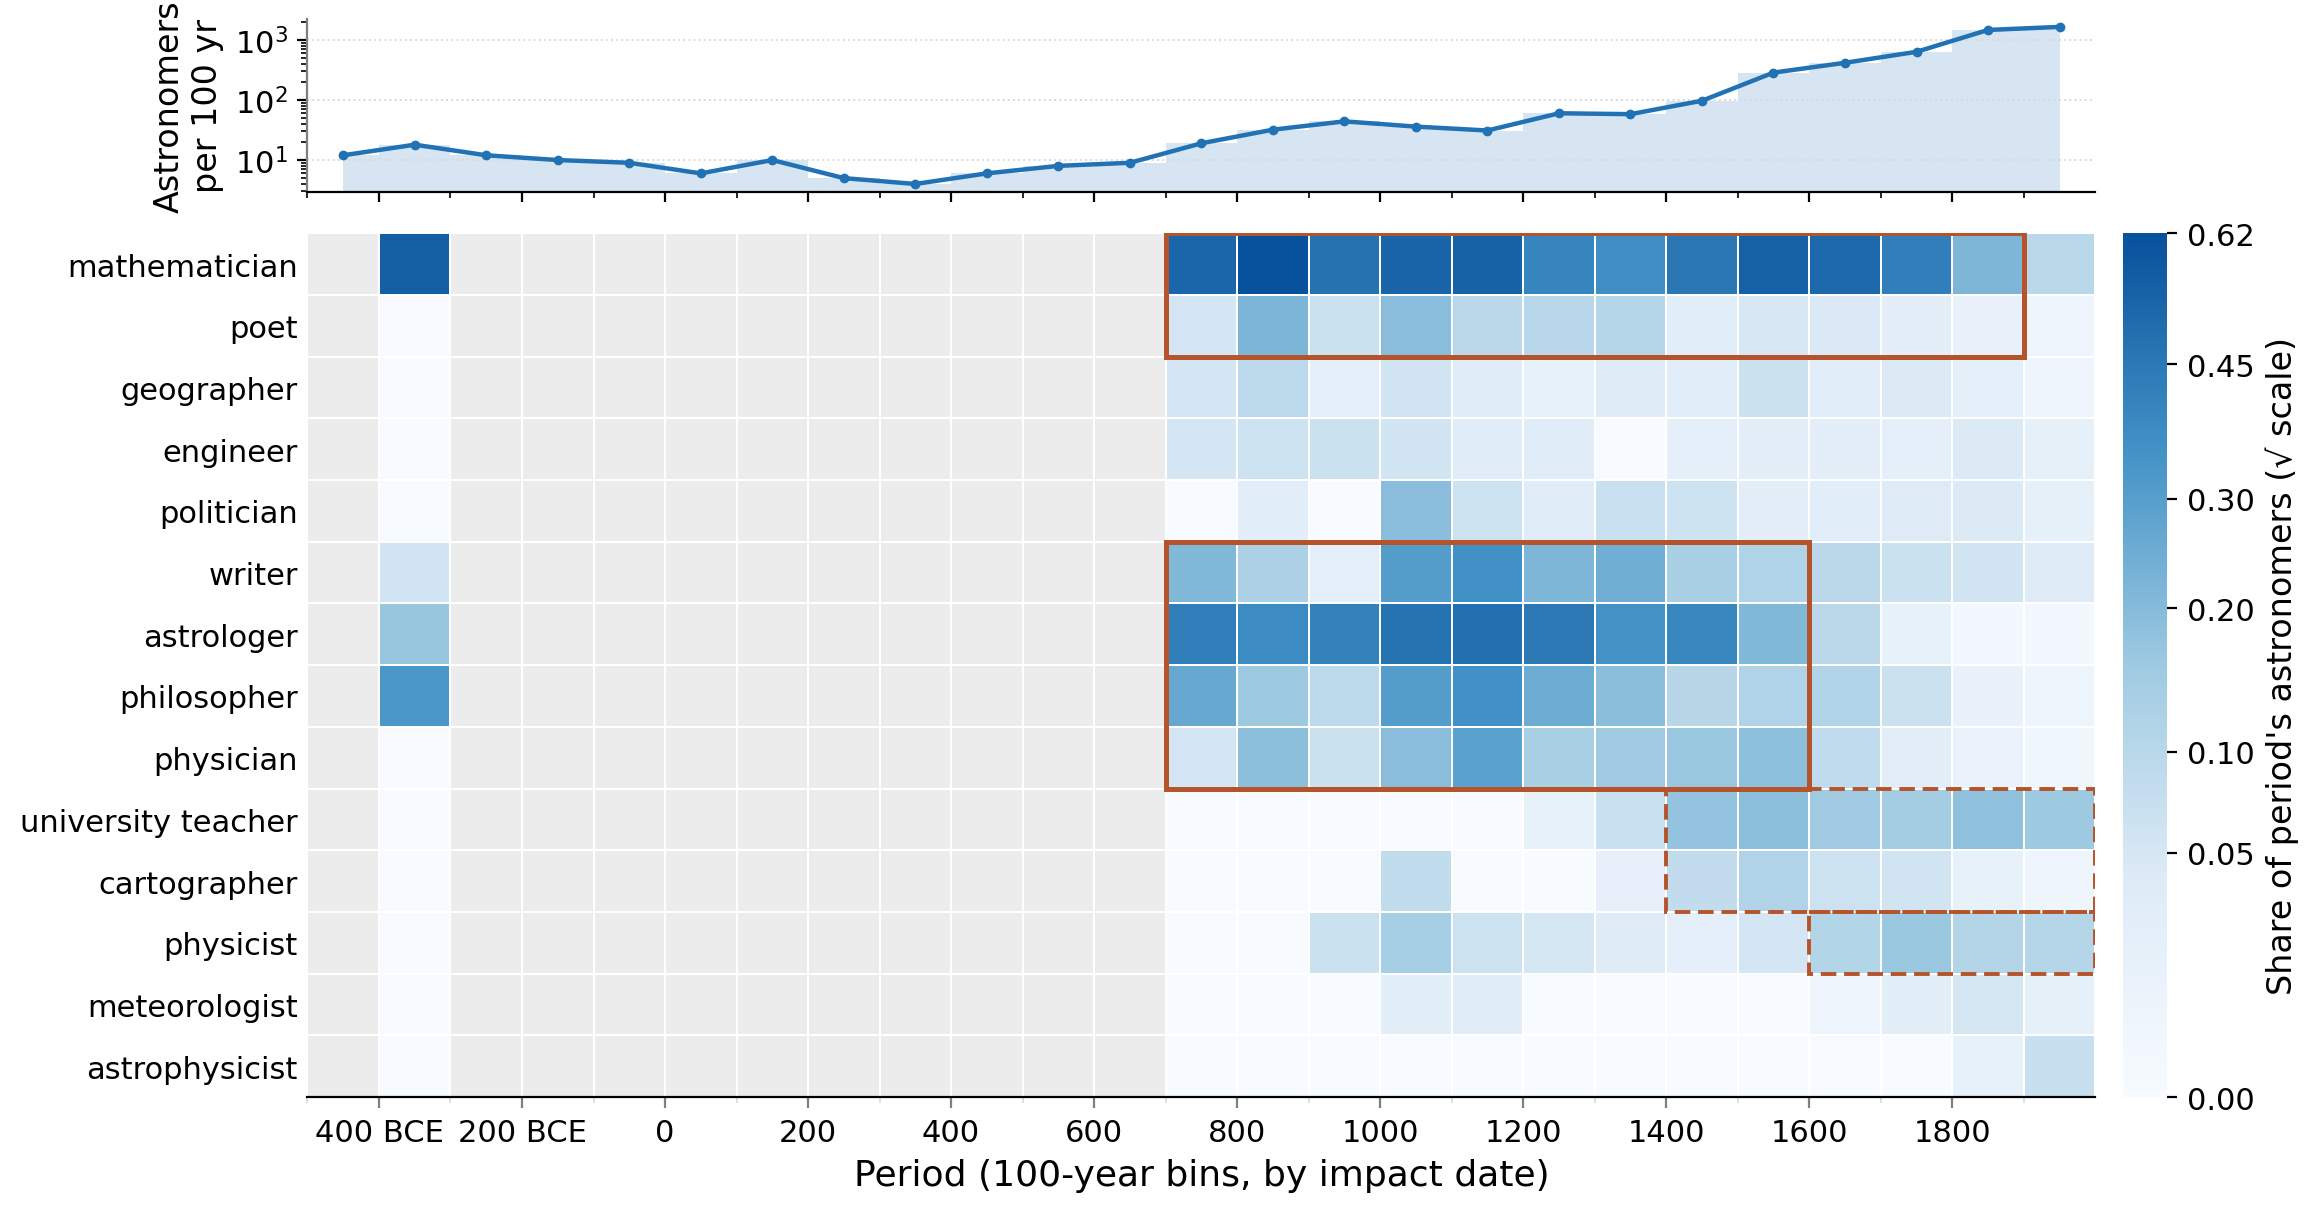

In [8]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.patches import Rectangle

# Light, single-hue cmap: very pale blue -> deep blue. NaN cells render in light gray.
cmap = LinearSegmentedColormap.from_list(
    "soft_blue", ["#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#08519c"]
)
cmap.set_bad(color="#ececec")

# Sqrt colour scale (gamma=0.5): boosts the visibility of low-share cells in the
# modern era without altering the underlying per-century normalisation of the data.
vmax = float(np.nanmax(matrix.values))
norm = PowerNorm(gamma=0.5, vmin=0, vmax=vmax)

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
gs = GridSpec(2, 2, height_ratios=[1, 5], width_ratios=[40, 1],
              hspace=0.08, wspace=0.03, figure=fig)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_cbar = fig.add_subplot(gs[1, 1])

x = np.array(all_periods)
x_centers = x + BIN_WIDTH / 2
edges_x = np.append(x, x[-1] + BIN_WIDTH)

# --- Top: count of astronomers per period ---
counts = n_per_period.reindex(all_periods).values.astype(float)
counts_plot = np.where(counts > 0, counts, np.nan)
ax_top.fill_between(x_centers, 0, np.where(np.isnan(counts_plot), 0, counts_plot),
                    step="mid", color=COLOR_PRIMARY, alpha=0.18, linewidth=0)
ax_top.plot(x_centers, counts_plot, color=COLOR_PRIMARY, linewidth=1.6, marker="o", markersize=2.5)
ax_top.set_ylabel("Astronomers\nper 100 yr", fontsize=FONT_LABEL - 1)
ax_top.tick_params(labelbottom=False)
ax_top.set_yscale("log")
ax_top.spines["left"].set_color(COLOR_NEUTRAL)
ax_top.grid(axis="y", linestyle=":", color=COLOR_LIGHT, linewidth=0.7)

# --- Main: heatmap (sqrt scale to make the modern era visible) ---
data = np.ma.masked_invalid(matrix.values)
edges_y = np.arange(len(matrix.index) + 1)
mesh = ax_main.pcolormesh(
    edges_x, edges_y, data,
    cmap=cmap, norm=norm,
    shading="flat", edgecolors="white", linewidth=0.6,
)
ax_main.set_yticks(np.arange(len(matrix.index)) + 0.5)
ax_main.set_yticklabels(matrix.index)
ax_main.invert_yaxis()
ax_main.set_xlabel("Period (100-year bins, by impact date)")
ax_main.set_xlim(edges_x[0], edges_x[-1])

# --- Cluster outlines: solid orange = strict regime, dashed = soft modern regime ---
STYLE = {
    "strict": dict(edgecolor="#b5542a", linewidth=1.8, linestyle="-"),
    "soft":   dict(edgecolor="#b5542a", linewidth=1.4, linestyle=(0, (4, 2))),
}
for b in blocks:
    x0 = matrix.columns[b["col_start"]]
    x1 = matrix.columns[b["col_stop"] - 1] + BIN_WIDTH
    y0, y1 = b["row_start"], b["row_stop"]
    ax_main.add_patch(Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        fill=False, joinstyle="miter", zorder=5,
        **STYLE[b["kind"]],
    ))

# Period tick labels every 200 years across the full range.
tick_step = 200
ticks = np.arange(int(np.ceil(YEAR_MIN / tick_step) * tick_step), YEAR_MAX + 1, tick_step)
ax_main.set_xticks(ticks)
ax_main.set_xticklabels([f"{t}" if t >= 0 else f"{abs(t)} BCE" for t in ticks])
ax_main.tick_params(axis="x", which="major", length=4, color=COLOR_NEUTRAL)
ax_main.set_xticks(x, minor=True)
ax_main.tick_params(axis="x", which="minor", length=2, color=COLOR_LIGHT)

for spine in ("top", "right", "left"):
    ax_main.spines[spine].set_visible(False)
ax_main.tick_params(axis="y", length=0)

cbar = fig.colorbar(mesh, cax=ax_cbar)
cbar.set_label("Share of period's astronomers (√ scale)", fontsize=FONT_LABEL - 1)
cbar.outline.set_visible(False)
# Tick labels show actual share values (0, 0.1, 0.2, …) on the sqrt-warped axis.
cbar_ticks = [0.0, 0.05, 0.10, 0.20, 0.30, 0.45, vmax]
cbar.set_ticks([t for t in cbar_ticks if t <= vmax])
cbar.set_ticklabels([f"{t:.2f}" for t in cbar_ticks if t <= vmax])

plt.show()

### Reading the figure

* The top panel makes the asymmetric coverage explicit: astronomer records are sparse before 1500 and explode after 1700.
* In the heatmap, **astrologer** dominates the medieval and early-modern bins and fades after ~1700, the historical moment when astronomy and astrology are institutionally separated.
* **Mathematician** and **philosopher** carry most of the early-modern weight; from the 19th century onward the dense rows shift to **physicist**, **university teacher**, **writer** — the modern academic profile.
* The diagonal-like pattern of the row ordering visualises the gradual conceptual drift from a polymath/astrology-adjacent figure to a specialised research scientist.